# Melanoma Classification — Scenario II & III
## Weighted Ensemble Optimisation + Cross-Dataset Evaluation

**Scenario II** — Bayesian Optimisation (TPE) is used to find optimal ensemble weights across four individually trained models. Weights are selected by maximising a dual objective (0.6 × Accuracy + 0.4 × AUC) on the held-out validation set.

**Scenario III** — The trained ensemble is evaluated on an independent dataset (DS2 / Mendeley) to assess cross-dataset generalisation, without any retraining.

> All individual model predictions (`.npy`) are loaded from local directories produced by the four Scenario I notebooks.


## 1. Installation


In [1]:
import subprocess, sys

required = [
    'torch', 'torchvision', 'timm', 'optuna',
    'scikit-learn', 'matplotlib', 'seaborn', 'pandas', 'numpy',
]

for pkg in required:
    subprocess.check_call(
        [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

print('All packages verified.')


All packages verified.


## 2. Imports & Environment


In [2]:
import os, json, warnings, random, math
from pathlib import Path
from copy import deepcopy
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve,
)
import timm
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = torch.cuda.is_available()

print(f'Device  : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
print(f'PyTorch : {torch.__version__}')
print(f'timm    : {timm.__version__}')
print(f'Optuna  : {optuna.__version__}')


Device  : cuda
GPU     : NVIDIA GeForce RTX 2050
PyTorch : 2.5.1+cu121
timm    : 1.0.22
Optuna  : 4.8.0


## 3. Configuration


In [ ]:
from pathlib import Path

BASE_DIR = Path(r'D:\Tree-Structured Parzen Estimator\main')

# Results produced by each Scenario I notebook
RESULTS = {
    'densenet121'  : BASE_DIR / 'densenet121' / 'full_pipeline_results',
    'inception_v3' : BASE_DIR / 'inceptionv3' / 'full_pipeline_results',
    'xception'     : BASE_DIR / 'xception'    / 'full_pipeline_results',
    'vit_scratch'  : BASE_DIR / 'vit'         / 'full_pipeline_results',
}

# Scenario II & III outputs
OUTPUT_DIR = BASE_DIR / 'ensemble_learning' / 'ensemble_results'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Model configuration ───────────────────────────────────────────────────────
NUM_CLASSES    = 2
TTA_STEPS      = 10
VIT_IMG_SIZE   = 224
VIT_MODEL_NAME = 'vit_small_patch16_224'
ENS_TRIALS     = 100

CNN_UNFREEZE = {1:'frozen', 5:'last_block', 10:'last_2_blocks', 18:'full'}

ARCH_CONFIGS = {
    'densenet121'  : {'label':'DenseNet-121', 'img_size':224, 'unfreeze_schedule':CNN_UNFREEZE},
    'inception_v3' : {'label':'InceptionV3',  'img_size':299, 'unfreeze_schedule':CNN_UNFREEZE},
    'xception'     : {'label':'Xception',     'img_size':299, 'unfreeze_schedule':CNN_UNFREEZE},
}

MODEL_LABELS = {
    'densenet121'  : 'DenseNet-121',
    'inception_v3' : 'InceptionV3',
    'xception'     : 'Xception',
    'vit_scratch'  : 'ViT-Pretrained',
}

MODEL_KEYS = ['densenet121', 'inception_v3', 'xception', 'vit_scratch']

PAPER_REF = {
    'DenseNet-121'  : {'accuracy':0.9450, 'precision':0.9390, 'recall':0.9504, 'f1':0.9447},
    'InceptionV3'   : {'accuracy':0.9120, 'precision':0.9320, 'recall':0.8962, 'f1':0.9137},
    'Xception'      : {'accuracy':0.9380, 'precision':0.9300, 'recall':0.9451, 'f1':0.9375},
    'ViT-Pretrained': {'accuracy':0.8825, 'precision':0.9050, 'recall':0.8660, 'f1':0.8850},
    'Ensemble'      : {'accuracy':0.9525, 'precision':0.9420, 'recall':0.9622, 'f1':0.9520},
}

CLASS_NAMES = ['Benign', 'Malignant']

# ── Verify all result directories exist ───────────────────────────────────────
print('Configuration loaded.')
print(f'  BASE_DIR   : {BASE_DIR}')
print(f'  OUTPUT_DIR : {OUTPUT_DIR}')
print()
all_ok = True
for arch, path in RESULTS.items():
    status = 'OK' if path.exists() else 'NOT FOUND'
    if not path.exists():
        all_ok = False
    print(f'  {MODEL_LABELS[arch]:<16} [{status}]  {path}')
print()
print('All directories found.' if all_ok else 'WARNING: Some directories are missing.')


Configuration loaded.
  BASE_DIR   : D:\Tree-Structured Parzen Estimator\main
  OUTPUT_DIR : D:\Tree-Structured Parzen Estimator\main\ensemble_results

  DenseNet-121     [OK]  D:\Tree-Structured Parzen Estimator\main\densenet121\full_pipeline_results
  InceptionV3      [OK]  D:\Tree-Structured Parzen Estimator\main\inceptionv3\full_pipeline_results
  Xception         [OK]  D:\Tree-Structured Parzen Estimator\main\xception\full_pipeline_results
  ViT-Pretrained   [OK]  D:\Tree-Structured Parzen Estimator\main\vit\full_pipeline_results

All directories found.


## 4. Evaluation Utilities


In [4]:
def compute_metrics(labels, probs, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    return {
        'accuracy'  : accuracy_score(labels, preds),
        'precision' : precision_score(labels, preds, zero_division=0),
        'recall'    : recall_score(labels, preds, zero_division=0),
        'f1'        : f1_score(labels, preds, zero_division=0),
        'auc'       : roc_auc_score(labels, probs),
        'conf_mat'  : confusion_matrix(labels, preds).tolist(),
        'threshold' : float(threshold),
    }

print('Evaluation utilities ready.')


Evaluation utilities ready.


---
## 5. Load Scenario I Results

Load pre-computed prediction arrays (`.npy`) from each Scenario I notebook. No retraining is performed.


In [5]:
import numpy as np

all_probs_ds1  = {}
all_val_probs  = {}
all_probs_ds2  = {}
all_metrics_ds1 = {}

print('Loading Scenario I prediction files...')
print()

for arch in MODEL_KEYS:
    d = RESULTS[arch]
    try:
        all_probs_ds1[arch] = np.load(d / f'probs_ds1_{arch}.npy')
        all_val_probs[arch] = np.load(d / f'val_probs_{arch}.npy')
        all_probs_ds2[arch] = np.load(d / f'probs_ds2_{arch}.npy')
        print(f'  {MODEL_LABELS[arch]:<16}  '
              f'DS1={all_probs_ds1[arch].shape}  '
              f'DS2={all_probs_ds2[arch].shape}  OK')
    except FileNotFoundError as e:
        print(f'  {MODEL_LABELS[arch]:<16}  MISSING: {e}')

# Labels — use densenet folder as reference (same across all models)
ref = RESULTS['densenet121']
ds1_labels     = np.load(ref / 'ds1_labels.npy')
ds2_labels     = np.load(ref / 'ds2_labels.npy')
all_val_labels = np.load(ref / 'val_labels.npy')

print()
print(f'  DS1 test labels  : {ds1_labels.shape}')
print(f'  DS2 test labels  : {ds2_labels.shape}')
print(f'  Validation labels: {all_val_labels.shape}')

# Compute DS1 metrics per model
print()
print('Individual model performance on DS1 test set:')
print(f'  {"Model":<16} {"Accuracy":>10} {"Recall":>8} {"F1":>8}  {"vs Paper":>10}')
print('  ' + '-' * 56)
for arch in MODEL_KEYS:
    if arch not in all_probs_ds1:
        continue
    m = compute_metrics(ds1_labels, all_probs_ds1[arch])
    all_metrics_ds1[arch] = m
    label = MODEL_LABELS[arch]
    delta = m['accuracy'] - PAPER_REF[label]['accuracy']
    mark  = '▲' if delta >= 0 else '▼'
    print(f'  {label:<16} {m["accuracy"]:>10.4f} '
          f'{m["recall"]:>8.4f} {m["f1"]:>8.4f}  '
          f'{delta:>+9.4f} {mark}')

# Load TPE params if available
tpe_best_params = {}
for arch in MODEL_KEYS:
    p = RESULTS[arch] / f'tpe_{arch}.json'
    if p.exists():
        with open(p) as f:
            tpe_best_params[arch] = json.load(f)

print()
print(f'{len(all_probs_ds1)}/{len(MODEL_KEYS)} models loaded successfully.')


Loading Scenario I prediction files...

  DenseNet-121      DS1=(2000,)  DS2=(1000,)  OK
  InceptionV3       DS1=(2000,)  DS2=(1000,)  OK
  Xception          DS1=(2000,)  DS2=(1000,)  OK
  ViT-Pretrained    DS1=(2000,)  DS2=(1000,)  OK

  DS1 test labels  : (2000,)
  DS2 test labels  : (1000,)
  Validation labels: (1782,)

Individual model performance on DS1 test set:
  Model              Accuracy   Recall       F1    vs Paper
  --------------------------------------------------------
  DenseNet-121         0.9520   0.9540   0.9521    +0.0070 ▲
  InceptionV3          0.9535   0.9410   0.9529    +0.0415 ▲
  Xception             0.9380   0.9250   0.9372    +0.0000 ▲
  ViT-Pretrained       0.9510   0.9310   0.9500    +0.0685 ▲

4/4 models loaded successfully.


---
## 6. Scenario II — Weighted Ensemble Optimisation

TPE optimises four normalised weights (one per model) by maximising a dual objective on the **validation set**. The test set is not used during weight search to prevent data leakage.

**Objective:** `0.6 × Accuracy + 0.4 × AUC`


In [6]:
def ensemble_predict(probs_dict, weights, keys):
    out = np.zeros_like(list(probs_dict.values())[0])
    for k, w in zip(keys, weights):
        out += w * probs_dict[k]
    return out


def ens_objective(trial):
    raw    = [trial.suggest_float(f'w_{k}', 0.05, 1.0) for k in MODEL_KEYS]
    w      = [r / sum(raw) for r in raw]
    probs  = ensemble_predict(all_val_probs, w, MODEL_KEYS)
    acc    = accuracy_score(all_val_labels, (probs >= 0.5).astype(int))
    try:
        auc = roc_auc_score(all_val_labels, probs)
    except Exception:
        auc = acc
    return 0.6 * acc + 0.4 * auc


print(f'Searching optimal ensemble weights ({ENS_TRIALS} trials)...')
print(f'Objective : 0.6 x Accuracy + 0.4 x AUC  |  Optimiser: multivariate TPE')
print()

ens_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(
        seed=SEED,
        n_startup_trials=20,
        multivariate=True,
        warn_independent_sampling=False,
    ),
    study_name='ensemble_weights')
ens_study.optimize(ens_objective, n_trials=ENS_TRIALS, show_progress_bar=True) # type: ignore

best_raw     = [ens_study.best_params[f'w_{k}'] for k in MODEL_KEYS]
best_weights = [r / sum(best_raw) for r in best_raw]
weights_dict = {k: float(w) for k, w in zip(MODEL_KEYS, best_weights)}

print(f'\nBest combined score : {ens_study.best_value:.4f}')
print()
print(f'  {"Model":<18} {"Weight":>8} {"Share":>8}')
print('  ' + '-' * 38)
for k, w in zip(MODEL_KEYS, best_weights):
    print(f'  {MODEL_LABELS[k]:<18} {w:>8.4f} {w*100:>7.1f}%')

with open(OUTPUT_DIR / 'ensemble_weights.json', 'w') as f:
    json.dump(weights_dict, f, indent=2)
print(f'\nWeights saved to: ensemble_weights.json')


Searching optimal ensemble weights (100 trials)...
Objective : 0.6 x Accuracy + 0.4 x AUC  |  Optimiser: multivariate TPE



  0%|          | 0/100 [00:00<?, ?it/s]


Best combined score : 0.9565

  Model                Weight    Share
  --------------------------------------
  DenseNet-121         0.2469    24.7%
  InceptionV3          0.1794    17.9%
  Xception             0.1213    12.1%
  ViT-Pretrained       0.4523    45.2%

Weights saved to: ensemble_weights.json


## 7. Ensemble Evaluation on DS1


  Scenario II — Individual Models + Ensemble vs Paper Reference
  Model              Accuracy  Precision   Recall       F1      AUC
  ----------------------------------------------------------------
  DenseNet-121         0.9520     0.9502   0.9540   0.9521   0.9874
  InceptionV3          0.9535     0.9651   0.9410   0.9529   0.9894
  Xception             0.9380     0.9497   0.9250   0.9372   0.9850
  ViT-Pretrained       0.9510     0.9698   0.9310   0.9500   0.9898
  ----------------------------------------------------------------
  Ensemble (ours)      0.9620     0.9686   0.9550   0.9617   0.9942
  Paper reference      0.9525     0.9420   0.9622   0.9520
  Delta (Ensemble ours - Paper):
    accuracy     +0.0095  OK
    precision    +0.0266  OK
    recall       -0.0072  BELOW
    f1           +0.0097  OK


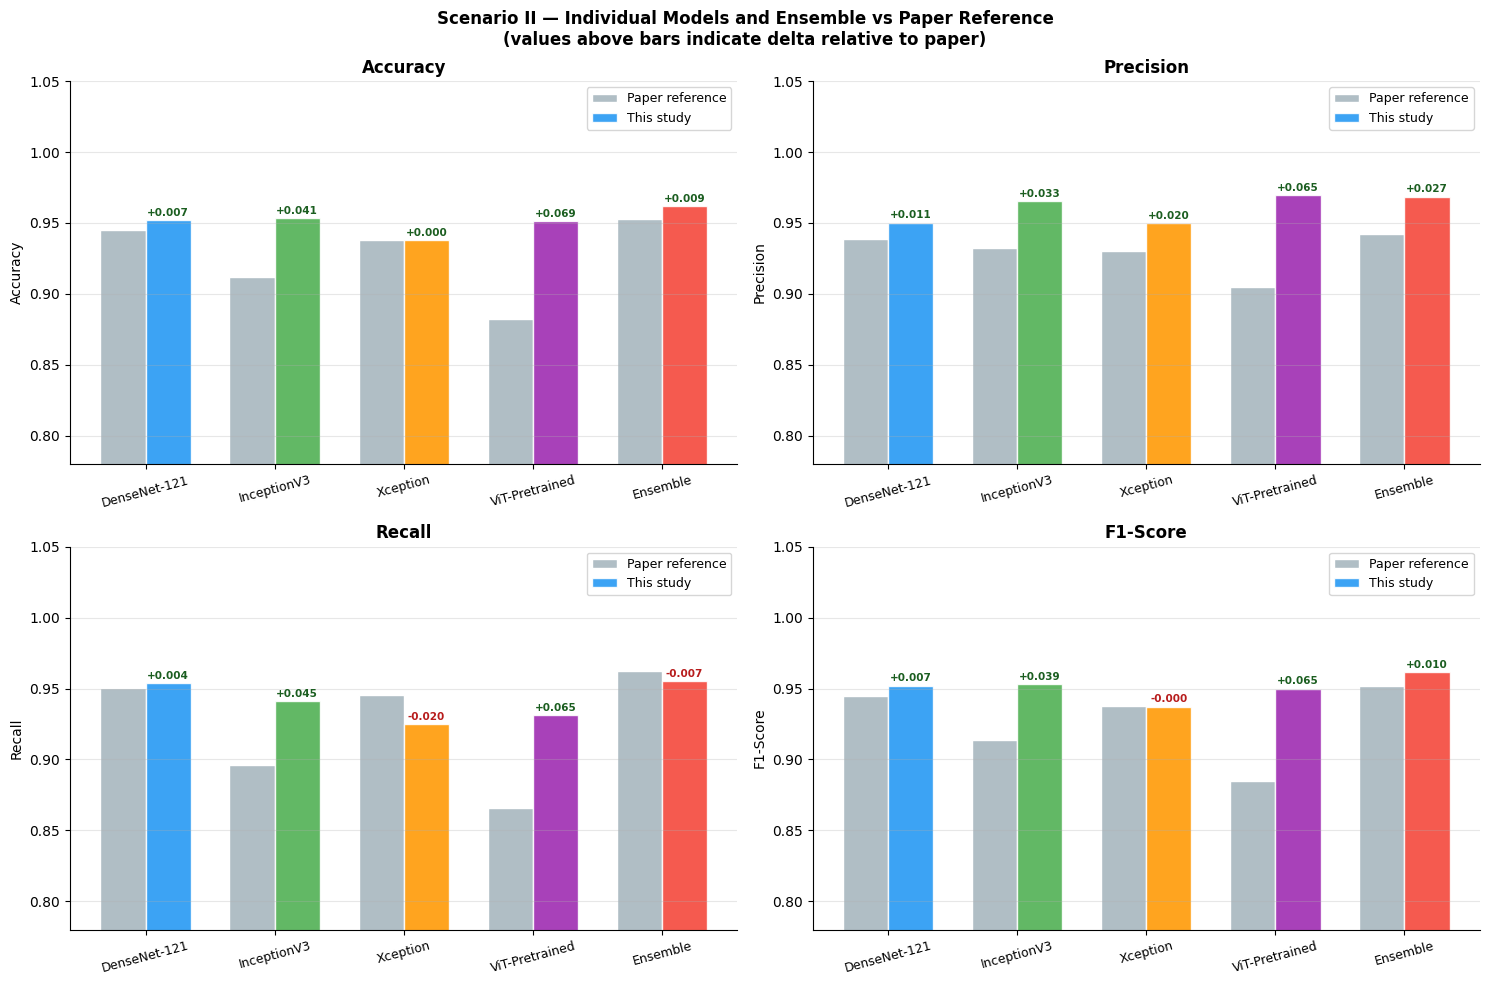

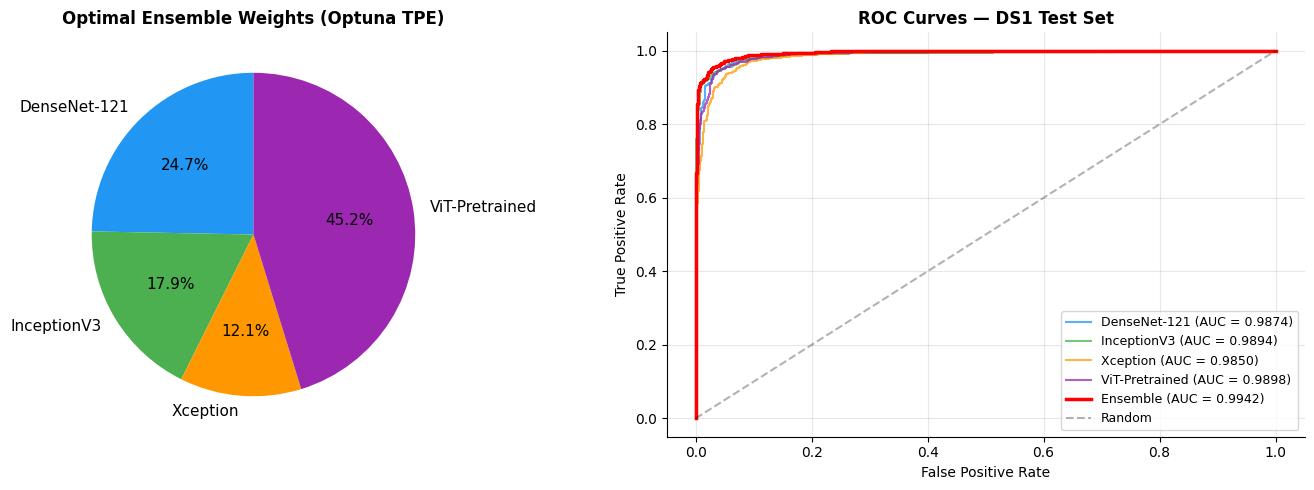

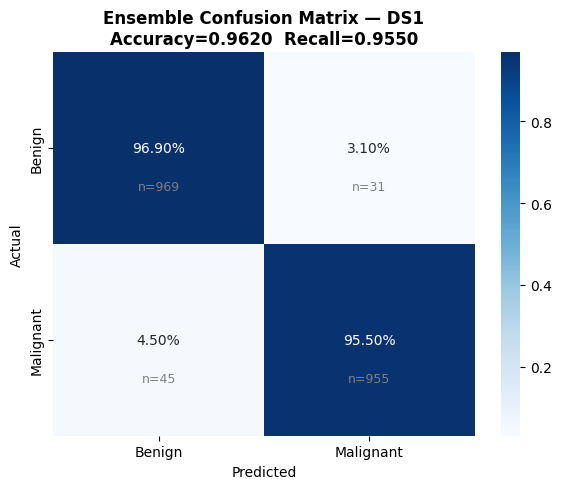

Scenario II outputs saved.


In [7]:
ens_probs   = ensemble_predict(all_probs_ds1, best_weights, MODEL_KEYS)
ens_metrics = compute_metrics(ds1_labels, ens_probs)
pens        = PAPER_REF['Ensemble']

# ── Performance table ─────────────────────────────────────────────────────────
print('=' * 66)
print('  Scenario II — Individual Models + Ensemble vs Paper Reference')
print('=' * 66)
print(f'  {"Model":<16} {"Accuracy":>10} {"Precision":>10} '
      f'{"Recall":>8} {"F1":>8} {"AUC":>8}')
print('  ' + '-' * 64)
for arch in MODEL_KEYS:
    m = all_metrics_ds1[arch]
    print(f'  {MODEL_LABELS[arch]:<16} {m["accuracy"]:>10.4f} '
          f'{m["precision"]:>10.4f} {m["recall"]:>8.4f} '
          f'{m["f1"]:>8.4f} {m["auc"]:>8.4f}')
print('  ' + '-' * 64)
print(f'  {"Ensemble (ours)":<16} {ens_metrics["accuracy"]:>10.4f} '
      f'{ens_metrics["precision"]:>10.4f} {ens_metrics["recall"]:>8.4f} '
      f'{ens_metrics["f1"]:>8.4f} {ens_metrics["auc"]:>8.4f}')
print(f'  {"Paper reference":<16} {pens["accuracy"]:>10.4f} '
      f'{pens["precision"]:>10.4f} {pens["recall"]:>8.4f} '
      f'{pens["f1"]:>8.4f}')
print('=' * 66)
print('  Delta (Ensemble ours - Paper):')
for k in ['accuracy', 'precision', 'recall', 'f1']:
    d = ens_metrics[k] - pens[k]
    print(f'    {k:<12} {d:>+.4f}  {"OK" if d >= 0 else "BELOW"}')

# ── Visualisation 1: grouped bar chart ───────────────────────────────────────
COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
plot_labels = [MODEL_LABELS[k] for k in MODEL_KEYS] + ['Ensemble']
metrics_p   = ['accuracy', 'precision', 'recall', 'f1']
m_labels    = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, metric, mlabel in zip(axes.flat, metrics_p, m_labels):
    ours  = [all_metrics_ds1[k][metric] for k in MODEL_KEYS] + [ens_metrics[metric]]
    paper = [PAPER_REF[MODEL_LABELS[k]][metric] for k in MODEL_KEYS] + [pens[metric]]
    x = np.arange(len(plot_labels))
    w = 0.35
    ax.bar(x - w/2, paper, w, label='Paper reference',
           color='#B0BEC5', edgecolor='white')
    bars = ax.bar(x + w/2, ours, w, label='This study',
                  color=COLORS[:len(ours)], edgecolor='white', alpha=0.88)
    for bar, pv, ov in zip(bars, paper, ours):
        d = ov - pv
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f'{d:+.3f}', ha='center', fontsize=7.5,
                color='#1B5E20' if d >= 0 else '#B71C1C',
                fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(plot_labels, rotation=15, fontsize=9)
    ax.set_ylabel(mlabel)
    ax.set_ylim([0.78, 1.05])
    ax.set_title(f'{mlabel}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle(
    'Scenario II — Individual Models and Ensemble vs Paper Reference\n'
    '(values above bars indicate delta relative to paper)',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scenario2_vs_paper.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# ── Visualisation 2: ensemble weights + ROC curves ────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.pie(best_weights,
        labels=[MODEL_LABELS[k] for k in MODEL_KEYS],
        autopct='%1.1f%%', colors=COLORS[:4],
        startangle=90, textprops={'fontsize': 11})
ax1.set_title('Optimal Ensemble Weights (Optuna TPE)', fontweight='bold')

for arch, color in zip(MODEL_KEYS, COLORS):
    fpr, tpr, _ = roc_curve(ds1_labels, all_probs_ds1[arch])
    auc = all_metrics_ds1[arch]['auc']
    ax2.plot(fpr, tpr, color=color, lw=1.5, alpha=0.75,
             label=f'{MODEL_LABELS[arch]} (AUC = {auc:.4f})')
fpr_e, tpr_e, _ = roc_curve(ds1_labels, ens_probs)
ax2.plot(fpr_e, tpr_e, color='red', lw=2.5,
         label=f'Ensemble (AUC = {ens_metrics["auc"]:.4f})')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curves — DS1 Test Set', fontweight='bold')
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scenario2_weights_roc.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# ── Visualisation 3: confusion matrix ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
cm = np.array(ens_metrics['conf_mat'])
sns.heatmap(cm.astype(float) / cm.sum(axis=1, keepdims=True),
            annot=True, fmt='.2%', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.72, f'n={cm[i,j]}',
                ha='center', fontsize=9, color='gray')
ax.set_title(
    f'Ensemble Confusion Matrix — DS1\n'
    f'Accuracy={ens_metrics["accuracy"]:.4f}  '
    f'Recall={ens_metrics["recall"]:.4f}',
    fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scenario2_confmat.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

with open(OUTPUT_DIR / 'scenario2_results.json', 'w') as f:
    json.dump({
        'ensemble'  : {k: v for k, v in ens_metrics.items() if k != 'conf_mat'},
        'individual': {k: {m: v for m, v in all_metrics_ds1[k].items()
                           if m != 'conf_mat'} for k in MODEL_KEYS},
        'weights'   : weights_dict,
        'paper_ref' : PAPER_REF,
    }, f, indent=2)
print('Scenario II outputs saved.')


---
## 8. Scenario III — Cross-Dataset Generalisation (DS2)

The ensemble and individual models are evaluated on DS2 (Mendeley / Hasnainjaved) using pre-computed prediction arrays. No retraining is performed — this is a zero-shot cross-dataset evaluation.


  Scenario III — Cross-Dataset Evaluation (DS1 vs DS2)
  Model              DS1 Acc   DS2 Acc    Delta   DS1 Rec   DS2 Rec  Paper Acc  vs Paper
  ----------------------------------------------------------------------------------
  DenseNet-121        0.9520    0.9700  +0.0180    0.9540    0.9760     0.9450   +0.0070
  InceptionV3         0.9535    0.9760  +0.0225    0.9410    0.9700     0.9120   +0.0415
  Xception            0.9380    0.9530  +0.0150    0.9250    0.9420     0.9380   +0.0000
  ViT-Pretrained      0.9510    0.9710  +0.0200    0.9310    0.9660     0.8825   +0.0685
  ----------------------------------------------------------------------------------
  Ensemble            0.9620    0.9740  +0.0120    0.9550    0.9700     0.9525   +0.0095


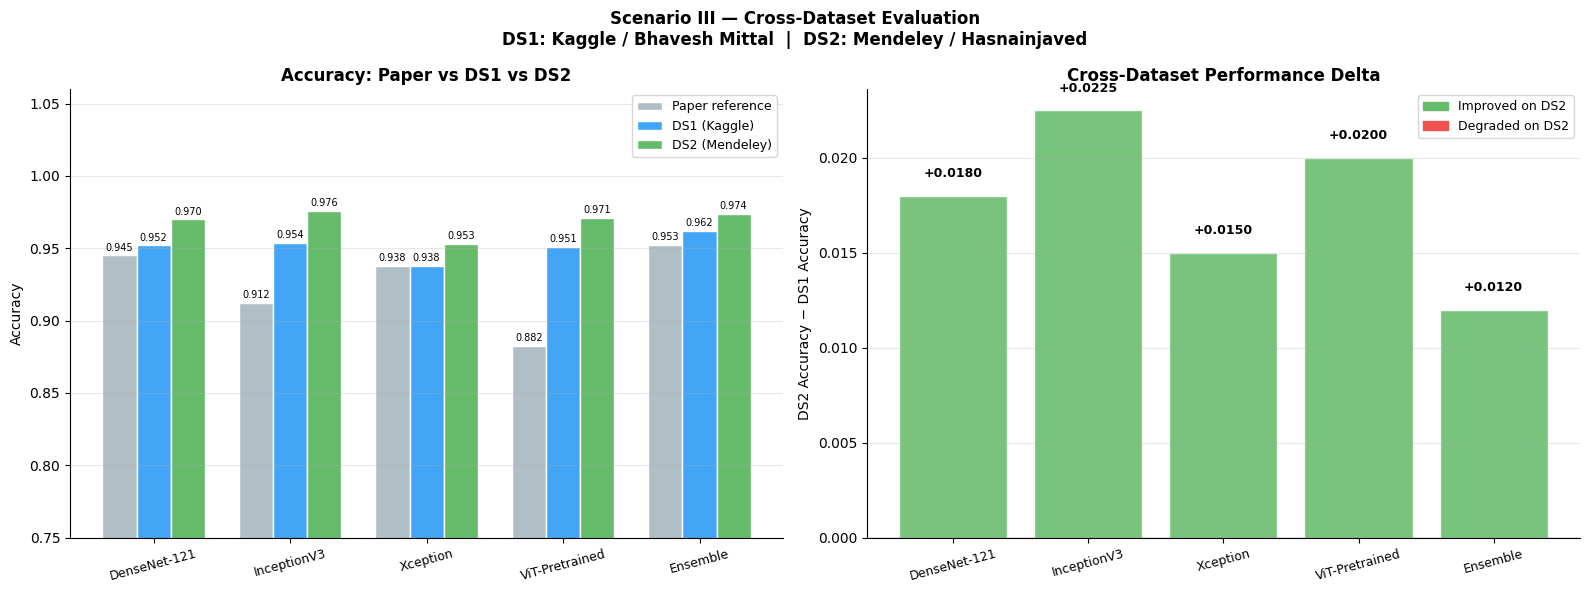

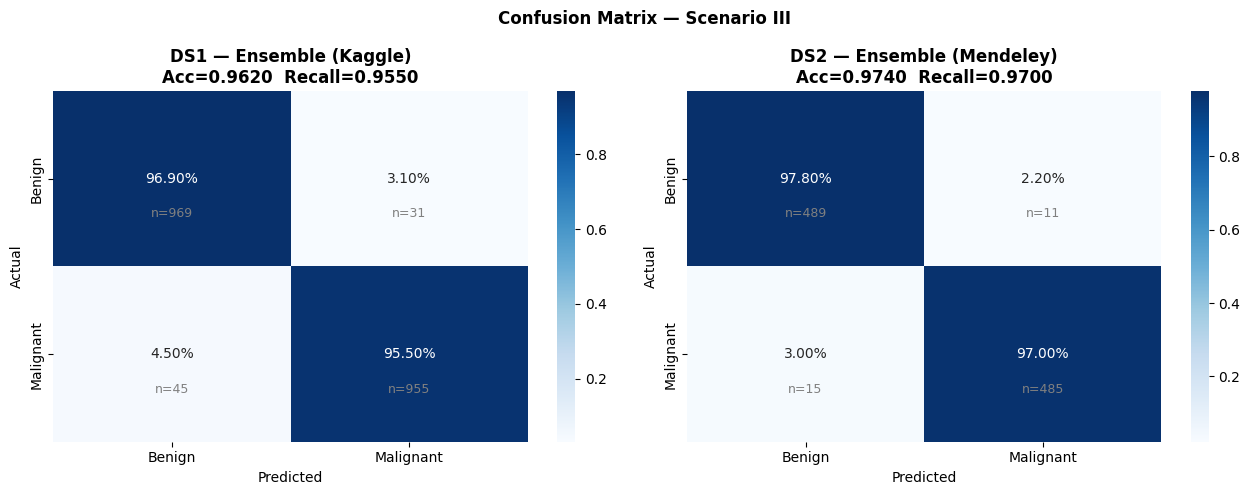

Scenario III outputs saved.


In [8]:
# DS2 probs already loaded in Cell 5 (all_probs_ds2)
ens_probs_ds2   = ensemble_predict(all_probs_ds2, best_weights, MODEL_KEYS)
ens_metrics_ds2 = compute_metrics(ds2_labels, ens_probs_ds2)

s3_metrics = {
    arch: compute_metrics(ds2_labels, all_probs_ds2[arch])
    for arch in MODEL_KEYS if arch in all_probs_ds2
}

pens = PAPER_REF['Ensemble']

# ── Performance table ─────────────────────────────────────────────────────────
print('=' * 84)
print('  Scenario III — Cross-Dataset Evaluation (DS1 vs DS2)')
print('=' * 84)
print(f'  {"Model":<16} {"DS1 Acc":>9} {"DS2 Acc":>9} '
      f'{"Delta":>8} {"DS1 Rec":>9} {"DS2 Rec":>9} '
      f'{"Paper Acc":>10} {"vs Paper":>9}')
print('  ' + '-' * 82)

for arch in MODEL_KEYS:
    if arch not in s3_metrics:
        continue
    label = MODEL_LABELS[arch]
    m1    = all_metrics_ds1[arch]
    m2    = s3_metrics[arch]
    p     = PAPER_REF[label]
    print(f'  {label:<16} '
          f'{m1["accuracy"]:>9.4f} {m2["accuracy"]:>9.4f} '
          f'{m2["accuracy"]-m1["accuracy"]:>+8.4f} '
          f'{m1["recall"]:>9.4f} {m2["recall"]:>9.4f} '
          f'{p["accuracy"]:>10.4f} '
          f'{m1["accuracy"]-p["accuracy"]:>+9.4f}')

print('  ' + '-' * 82)
print(f'  {"Ensemble":<16} '
      f'{ens_metrics["accuracy"]:>9.4f} {ens_metrics_ds2["accuracy"]:>9.4f} '
      f'{ens_metrics_ds2["accuracy"]-ens_metrics["accuracy"]:>+8.4f} '
      f'{ens_metrics["recall"]:>9.4f} {ens_metrics_ds2["recall"]:>9.4f} '
      f'{pens["accuracy"]:>10.4f} '
      f'{ens_metrics["accuracy"]-pens["accuracy"]:>+9.4f}')
print('=' * 84)

# ── Visualisation 1: DS1 vs DS2 vs Paper bar chart ───────────────────────────
valid_keys = [k for k in MODEL_KEYS if k in s3_metrics]
plot_lbs   = [MODEL_LABELS[k] for k in valid_keys] + ['Ensemble']
paper_accs = [PAPER_REF[MODEL_LABELS[k]]['accuracy'] for k in valid_keys] + [pens['accuracy']]
ds1_accs   = [all_metrics_ds1[k]['accuracy'] for k in valid_keys] + [ens_metrics['accuracy']]
ds2_accs   = [s3_metrics[k]['accuracy'] for k in valid_keys] + [ens_metrics_ds2['accuracy']]

x = np.arange(len(plot_lbs))
w = 0.25
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.bar(x - w, paper_accs, w, label='Paper reference', color='#B0BEC5', edgecolor='white')
ax.bar(x,     ds1_accs,   w, label='DS1 (Kaggle)',    color='#42A5F5', edgecolor='white')
ax.bar(x + w, ds2_accs,   w, label='DS2 (Mendeley)',  color='#66BB6A', edgecolor='white')
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', fontsize=7, padding=2)
ax.set_xticks(x)
ax.set_xticklabels(plot_lbs, rotation=15, fontsize=9)
ax.set_ylim([0.75, 1.06])
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy: Paper vs DS1 vs DS2', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

ax = axes[1]
deltas = [d2 - d1 for d1, d2 in zip(ds1_accs, ds2_accs)]
colors = ['#66BB6A' if d >= 0 else '#EF5350' for d in deltas]
bars   = ax.bar(plot_lbs, deltas, color=colors, edgecolor='white', alpha=0.88)
for bar, val in zip(bars, deltas):
    yp = bar.get_height() + 0.001 if val >= 0 else bar.get_height() - 0.006
    ax.text(bar.get_x() + bar.get_width() / 2, yp,
            f'{val:+.4f}', ha='center', fontsize=9, fontweight='bold')
ax.axhline(0, color='black', lw=1, alpha=0.4)
ax.set_ylabel('DS2 Accuracy − DS1 Accuracy')
ax.set_title('Cross-Dataset Performance Delta', fontweight='bold')
ax.set_xticklabels(plot_lbs, rotation=15, fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(handles=[
    mpatches.Patch(color='#66BB6A', label='Improved on DS2'),
    mpatches.Patch(color='#EF5350', label='Degraded on DS2'),
], fontsize=9)

plt.suptitle(
    'Scenario III — Cross-Dataset Evaluation\n'
    'DS1: Kaggle / Bhavesh Mittal  |  DS2: Mendeley / Hasnainjaved',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scenario3_comparison.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# ── Visualisation 2: confusion matrices DS1 vs DS2 ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (title, ds_m) in zip(axes, [
    ('DS1 — Ensemble (Kaggle)',    ens_metrics),
    ('DS2 — Ensemble (Mendeley)',  ens_metrics_ds2),
]):
    cm = np.array(ds_m['conf_mat'])
    sns.heatmap(cm.astype(float) / cm.sum(axis=1, keepdims=True),
                annot=True, fmt='.2%', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.72, f'n={cm[i,j]}',
                    ha='center', fontsize=9, color='gray')
    ax.set_title(
        f'{title}\nAcc={ds_m["accuracy"]:.4f}  Recall={ds_m["recall"]:.4f}',
        fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix — Scenario III', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scenario3_confmat.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

with open(OUTPUT_DIR / 'scenario3_results.json', 'w') as f:
    json.dump({
        'ds1_ensemble' : {k: v for k, v in ens_metrics.items()     if k != 'conf_mat'},
        'ds2_ensemble' : {k: v for k, v in ens_metrics_ds2.items() if k != 'conf_mat'},
        'individual_ds1': {k: {m: v for m, v in all_metrics_ds1[k].items()
                               if m != 'conf_mat'} for k in MODEL_KEYS if k in all_metrics_ds1},
        'individual_ds2': {k: {m: v for m, v in s3_metrics[k].items()
                               if m != 'conf_mat'} for k in MODEL_KEYS if k in s3_metrics},
        'paper_ref'    : PAPER_REF,
    }, f, indent=2)
print('Scenario III outputs saved.')


## 9. Final Summary


In [9]:
print('=' * 78)
print('  Final Summary — Scenario I + II + III vs Paper Reference')
print('=' * 78)

rows = []
for arch in MODEL_KEYS:
    label = MODEL_LABELS[arch]
    m1    = all_metrics_ds1.get(arch, {})
    m3    = s3_metrics.get(arch, {})
    paper = PAPER_REF[label]
    bp    = tpe_best_params.get(arch, {})
    rows.append({
        'Model'         : label,
        'Paper Acc'     : f"{paper['accuracy']:.4f}",
        'DS1 Acc'       : f"{m1.get('accuracy', 0):.4f}",
        'DS2 Acc'       : f"{m3.get('accuracy', 0):.4f}",
        'DS1 Recall'    : f"{m1.get('recall', 0):.4f}",
        'DS1 AUC'       : f"{m1.get('auc', 0):.4f}",
        'Delta Acc'     : f"{m1.get('accuracy', 0) - paper['accuracy']:+.4f}",
        'Best LR'       : f"{bp.get('lr', 0):.2e}" if bp else '-',
        'Optimiser'     : bp.get('optimizer_name', '-'),
    })

rows.append({
    'Model'         : 'Ensemble',
    'Paper Acc'     : f"{pens['accuracy']:.4f}",
    'DS1 Acc'       : f"{ens_metrics['accuracy']:.4f}",
    'DS2 Acc'       : f"{ens_metrics_ds2['accuracy']:.4f}",
    'DS1 Recall'    : f"{ens_metrics['recall']:.4f}",
    'DS1 AUC'       : f"{ens_metrics['auc']:.4f}",
    'Delta Acc'     : f"{ens_metrics['accuracy'] - pens['accuracy']:+.4f}",
    'Best LR'       : '-',
    'Optimiser'     : '-',
})

df = pd.DataFrame(rows)
display(df)
df.to_csv(OUTPUT_DIR / 'final_summary.csv', index=False)

delta = ens_metrics['accuracy'] - pens['accuracy']
print()
print(f'Ensemble DS1  : acc={ens_metrics["accuracy"]:.4f}  '
      f'recall={ens_metrics["recall"]:.4f}  '
      f'AUC={ens_metrics["auc"]:.4f}')
print(f'Ensemble DS2  : acc={ens_metrics_ds2["accuracy"]:.4f}  '
      f'recall={ens_metrics_ds2["recall"]:.4f}')
print(f'Paper target  : acc={pens["accuracy"]:.4f}  '
      f'recall={pens["recall"]:.4f}')
print(f'Delta vs paper: {delta:+.4f}  '
      f'({"Exceeds target" if delta >= 0 else "Below target"})')
print()
print(f'All outputs saved to: {OUTPUT_DIR}')
print()
for fp in sorted(OUTPUT_DIR.glob('*')):
    if fp.is_file():
        print(f'  {fp.name:<45} ({fp.stat().st_size / 1024:.1f} KB)')


  Final Summary — Scenario I + II + III vs Paper Reference


,Model,Paper Acc,DS1 Acc,DS2 Acc,DS1 Recall,DS1 AUC,Delta Acc,Best LR,Optimiser
0,DenseNet-121,0.9450,0.9520,0.9700,0.9540,0.9874,+0.0070,9.03e-03,adamax
1,InceptionV3,0.9120,0.9535,0.9760,0.9410,0.9894,+0.0415,3.33e-03,adamw
2,Xception,0.9380,0.9380,0.9530,0.9250,0.9850,+0.0000,4.33e-04,adam
3,ViT-Pretrained,0.8825,0.9510,0.9710,0.9310,0.9898,+0.0685,-,-
4,Ensemble,0.9525,0.9620,0.9740,0.9550,0.9942,+0.0095,-,-



Ensemble DS1  : acc=0.9620  recall=0.9550  AUC=0.9942
Ensemble DS2  : acc=0.9740  recall=0.9700
Paper target  : acc=0.9525  recall=0.9622
Delta vs paper: +0.0095  (Exceeds target)

All outputs saved to: D:\Tree-Structured Parzen Estimator\main\ensemble_results

  ensemble_weights.json                         (0.2 KB)
  final_summary.csv                             (0.4 KB)
  scenario2_confmat.png                         (42.0 KB)
  scenario2_results.json                        (1.8 KB)
  scenario2_vs_paper.png                        (133.7 KB)
  scenario2_weights_roc.png                     (107.2 KB)
  scenario3_comparison.png                      (110.1 KB)
  scenario3_confmat.png                         (67.4 KB)
  scenario3_results.json                        (2.6 KB)


[DenseNet-121 | DS1]  TP=954  FP=50  FN=46  TN=950
[DenseNet-121 | DS2]  TP=488  FP=18  FN=12  TN=482
[InceptionV3 | DS1]  TP=941  FP=34  FN=59  TN=966
[InceptionV3 | DS2]  TP=485  FP=9  FN=15  TN=491
[ViT | DS1]  TP=931  FP=29  FN=69  TN=971
[ViT | DS2]  TP=483  FP=12  FN=17  TN=488
[Xception | DS1]  TP=925  FP=49  FN=75  TN=951
[Xception | DS2]  TP=471  FP=18  FN=29  TN=482

Gambar disimpan di: D:\Tree-Structured Parzen Estimator\main\ensemble_learning\ensemble_results\confusion_matrix_all_models.png


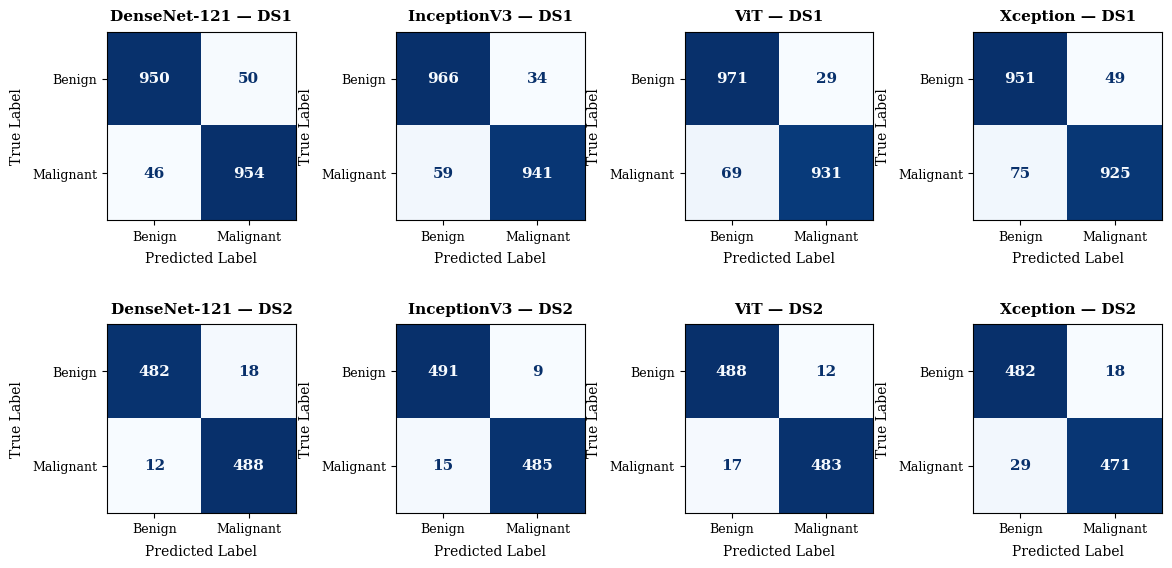

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix


ROOT   = r"D:\Tree-Structured Parzen Estimator\main"
OUTPUT = r"D:\Tree-Structured Parzen Estimator\main\ensemble_learning\ensemble_results"

MODELS = [
    {
        "name":      "DenseNet-121",
        "base":      rf"{ROOT}\densenet121\full_pipeline_results",
        "probs_ds1": "probs_ds1_densenet121.npy",
        "probs_ds2": "probs_ds2_densenet121.npy",
    },
    {
        "name":      "InceptionV3",
        "base":      rf"{ROOT}\inceptionv3\full_pipeline_results",
        "probs_ds1": "probs_ds1_inception_v3.npy",
        "probs_ds2": "probs_ds2_inception_v3.npy",
    },
    {
        "name":      "ViT",
        "base":      rf"{ROOT}\vit\full_pipeline_results",
        "probs_ds1": "probs_ds1_vit_scratch.npy",
        "probs_ds2": "probs_ds2_vit_scratch.npy",
    },
    {
        "name":      "Xception",
        "base":      rf"{ROOT}\xception\full_pipeline_results",
        "probs_ds1": "probs_ds1_xception.npy",
        "probs_ds2": "probs_ds2_xception.npy",
    },
]


plt.rcParams.update({
    "font.family":    "serif",
    "font.size":      10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})


fig, axes = plt.subplots(2, 4, figsize=(11.69, 5.80))
fig.patch.set_alpha(0.0)
fig.subplots_adjust(
    left=0.06,  right=0.98,
    top=0.93,   bottom=0.10,
    hspace=0.55, wspace=0.38
)

DS_TAGS = ["DS1", "DS2"]

for col, model in enumerate(MODELS):
    base = model["base"]

    labels_ds1 = np.load(rf"{base}\ds1_labels.npy")
    labels_ds2 = np.load(rf"{base}\ds2_labels.npy")
    probs_ds1  = np.load(rf"{base}\{model['probs_ds1']}")
    probs_ds2  = np.load(rf"{base}\{model['probs_ds2']}")

    preds_ds1 = (probs_ds1 >= 0.5).astype(int)
    preds_ds2 = (probs_ds2 >= 0.5).astype(int)

    for row, (labels, preds, ds_tag) in enumerate([
        (labels_ds1, preds_ds1, "DS1"),
        (labels_ds2, preds_ds2, "DS2"),
    ]):
        ax = axes[row, col]
        ax.set_facecolor("none")   # axes background → transparan

        cm = confusion_matrix(labels, preds)
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["Benign", "Malignant"]
        )
        disp.plot(ax=ax, cmap="Blues", colorbar=False)


        for text in ax.texts:
            text.set_fontsize(11)
            text.set_fontweight("bold")

        ax.set_title(f"{model['name']} — {ds_tag}",
                     fontsize=11, fontweight="bold", pad=8)
        ax.set_xlabel("Predicted Label", fontsize=10, labelpad=6)
        ax.set_ylabel("True Label",      fontsize=10, labelpad=6)
        ax.tick_params(axis="both", labelsize=9)

        tn, fp, fn, tp = cm.ravel()
        print(f"[{model['name']} | {ds_tag}]  TP={tp}  FP={fp}  FN={fn}  TN={tn}")


out_path = rf"{OUTPUT}\confusion_matrix_all_models.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight",
            transparent=True)
print(f"\nGambar disimpan di: {out_path}")
plt.show()